In [ ]:
from google.colab import files
uploaded = files.upload()

Saving dataset.zip to dataset.zip


In [ ]:
import zipfile
with zipfile.ZipFile("dataset.zip", 'r') as zip_ref:
    zip_ref.extractall("/content/dataset/")

print("Unzipped files:")
print(os.listdir("/content/dataset/"))

Unzipped files:
['dataset']


In [ ]:
import os
import cv2

dataset_path = "/content/dataset/dataset"  # fixed path

def verify_dataset(dataset_path):
    if not os.path.exists(dataset_path):
        print(f"Dataset path does not exist: {dataset_path}")
        return

    print(f"✅ Checking dataset structure at: {dataset_path}\n")

    for landmark in os.listdir(dataset_path):
        landmark_path = os.path.join(dataset_path, landmark)
        if not os.path.isdir(landmark_path):
            continue

        n_path = os.path.join(landmark_path, 'n')
        p_path = os.path.join(landmark_path, 'p')

        n_images = os.listdir(n_path) if os.path.exists(n_path) else []
        p_images = os.listdir(p_path) if os.path.exists(p_path) else []

        print(f"🔹 {landmark}")
        print(f"   - n/: {len(n_images)} images")
        print(f"   - p/: {len(p_images)} images")

        for folder, image_list in [(n_path, n_images), (p_path, p_images)]:
            for img_file in image_list[:1]:
                img_path = os.path.join(folder, img_file)
                img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
                if img is None:
                    print(f"   ⚠️ Failed to load image: {img_path}")
                else:
                    sift = cv2.SIFT_create()
                    kp, des = sift.detectAndCompute(img, None)
                    if des is None:
                        print(f"   ⚠️ No descriptors found in: {img_path}")
                    else:
                        print(f"   ✅ SIFT OK: {img_file} ({len(kp)} keypoints)")
                break

verify_dataset(dataset_path)


✅ Checking dataset structure at: /content/dataset/dataset

🔹 Atlantis
   - n/: 62 images
   - p/: 15 images
   ✅ SIFT OK: Burj_Khalifa_07.jpg (1029 keypoints)
   ✅ SIFT OK: Atlantis_07.jpg (3098 keypoints)
🔹 Burj Khalifa
   - n/: 51 images
   - p/: 25 images
   ✅ SIFT OK: Burj_Al_Arab_13.jpg (3619 keypoints)
   ✅ SIFT OK: Burj_Khalifa_07.jpg (1029 keypoints)
🔹 Dubai Frame
   - n/: 62 images
   - p/: 15 images
   ✅ SIFT OK: Burj_Khalifa_07.jpg (1029 keypoints)
   ✅ SIFT OK: Dubai_Frame_06.jpg (909 keypoints)
🔹 Burj Al Arab
   - n/: 61 images
   - p/: 16 images
   ✅ SIFT OK: Burj_Khalifa_07.jpg (1029 keypoints)
   ✅ SIFT OK: Burj_Al_Arab_13.jpg (3619 keypoints)


In [ ]:
import cv2
import numpy as np
import os
import joblib
from sklearn.cluster import MiniBatchKMeans
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler

landmarks = ["Atlantis", "Burj Al Arab", "Burj Khalifa", "Dubai Frame"]
dataset_path = "./dataset/dataset"
num_clusters = 200

def get_image_paths(folder):
    exts = ('.jpg', '.jpeg', '.png', '.bmp')
    return [os.path.join(folder, f) for f in os.listdir(folder) if f.lower().endswith(exts)]

def rootsift(descriptors):
    eps = 1e-7
    l1_norm = descriptors / (np.linalg.norm(descriptors, ord=1, axis=1, keepdims=True) + eps)
    return np.sqrt(l1_norm)

def extract_descriptors_with_rootsift(image_paths, sift):
    all_descriptors = []
    for img_path in image_paths:
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        if img is None:
            continue
        kp, des = sift.detectAndCompute(img, None)
        if des is not None:
            des = rootsift(des)
            all_descriptors.append(des)
    if len(all_descriptors) == 0:
        return None
    return np.vstack(all_descriptors)

def build_histograms(image_paths, sift, kmeans):
    histograms = []
    for img_path in image_paths:
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        if img is None:
            continue
        kp, des = sift.detectAndCompute(img, None)
        if des is None:
            histograms.append(np.zeros(kmeans.n_clusters, dtype=np.float32))
            continue
        des = rootsift(des)
        words = kmeans.predict(des)
        hist, _ = np.histogram(words, bins=np.arange(kmeans.n_clusters + 1))
        hist = hist.astype('float32')
        hist /= (hist.sum() + 1e-7)
        histograms.append(hist)
    return np.array(histograms)

def train_and_save_models():
    sift = cv2.SIFT_create(contrastThreshold=0.01, edgeThreshold=5)

    for lm in landmarks:
        print(f"\nTraining for {lm}...")

        pos_folder = os.path.join(dataset_path, lm, "p")
        neg_folder = os.path.join(dataset_path, lm, "n")

        pos_imgs = get_image_paths(pos_folder)
        neg_imgs = get_image_paths(neg_folder)

        pos_des = extract_descriptors_with_rootsift(pos_imgs, sift)
        neg_des = extract_descriptors_with_rootsift(neg_imgs, sift)

        if pos_des is None or neg_des is None:
            print(f"Skipping {lm}: no descriptors found.")
            continue

        all_des = np.vstack([pos_des, neg_des])

        kmeans = MiniBatchKMeans(n_clusters=num_clusters, random_state=42)
        kmeans.fit(all_des)

        pos_hist = build_histograms(pos_imgs, sift, kmeans)
        neg_hist = build_histograms(neg_imgs, sift, kmeans)

        X = np.vstack([pos_hist, neg_hist])
        y = np.hstack([np.ones(len(pos_hist)), np.zeros(len(neg_hist))])

        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(X)

        clf = SVC(kernel='rbf', probability=True, random_state=42)
        clf.fit(X_scaled, y)

        probs = clf.predict_proba(X_scaled)
        pos_class_index = list(clf.classes_).index(1)
        pos_scores = probs[:len(pos_hist), pos_class_index]
        neg_scores = probs[len(pos_hist):, pos_class_index]

        print(f"Average positive image score: {pos_scores.mean():.4f}")
        print(f"Average negative image score: {neg_scores.mean():.4f}")
        print(f"Training accuracy: {clf.score(X_scaled, y):.4f}")

        base_name = lm.replace(' ', '_')
        joblib.dump(kmeans, f"kmeans_{base_name}.pkl")
        joblib.dump(scaler, f"scaler_{base_name}.pkl")
        joblib.dump(clf, f"classifier_{base_name}.pkl")

        print(f"Saved models for {lm}")

if __name__ == "__main__":
    train_and_save_models()



Training for Atlantis...
Average positive image score: 0.9638
Average negative image score: 0.0266
Training accuracy: 0.9733
Saved models for Atlantis

Training for Burj Al Arab...
Average positive image score: 0.9024
Average negative image score: 0.0339
Training accuracy: 0.9733
Saved models for Burj Al Arab

Training for Burj Khalifa...
Average positive image score: 0.8937
Average negative image score: 0.0483
Training accuracy: 0.9595
Saved models for Burj Khalifa

Training for Dubai Frame...
Average positive image score: 0.8928
Average negative image score: 0.0709
Training accuracy: 0.9200
Saved models for Dubai Frame


In [ ]:
import joblib
import cv2
import numpy as np
import os
import matplotlib.pyplot as plt

landmarks = ["Atlantis", "Burj Al Arab", "Burj Khalifa", "Dubai Frame"]
dataset_path = "./dataset/dataset"

# Load all models for each landmark
models = {}
for lm in landmarks:
    try:
        clf = joblib.load(f"classifier_{lm.replace(' ', '_')}.pkl")
        kmeans = joblib.load(f"kmeans_{lm.replace(' ', '_')}.pkl")
        scaler = joblib.load(f"scaler_{lm.replace(' ', '_')}.pkl")
        models[lm] = {"clf": clf, "kmeans": kmeans, "scaler": scaler}
        print(f"Loaded models for {lm}")
    except Exception as e:
        print(f"Failed to load models for {lm}: {e}")

def compute_bovw_histogram(img_gray, sift, kmeans):
    kp, des = sift.detectAndCompute(img_gray, None)
    if des is None:
        return None, None
    words = kmeans.predict(des)
    hist, _ = np.histogram(words, bins=np.arange(kmeans.n_clusters + 1))
    hist = hist.astype('float32')
    hist /= (hist.sum() + 1e-7)
    hist = hist.reshape(1, -1)
    return hist, (kp, des)

def match_all_landmarks_sift(query_img_path, threshold=0.65, margin=0.05):
    sift = cv2.SIFT_create()
    query_img = cv2.imread(query_img_path, cv2.IMREAD_GRAYSCALE)
    if query_img is None:
        print("Query image not found or cannot be read.")
        return

    scores = []
    best_kp_des = None

    print("\n--- Landmark Match Probabilities ---")
    for lm, mdl in models.items():
        hist, kp_des = compute_bovw_histogram(query_img, sift, mdl["kmeans"])
        if hist is None:
            print(f"{lm}: No descriptors found.")
            continue

        hist_scaled = mdl["scaler"].transform(hist)
        clf = mdl["clf"]
        proba = clf.predict_proba(hist_scaled)[0]
        pos_class_idx = list(clf.classes_).index(1)
        score = proba[pos_class_idx]
        scores.append((lm, score, kp_des))
        print(f"{lm}: positive class probability = {score:.4f}")

    scores.sort(key=lambda x: x[1], reverse=True)

    if not scores or scores[0][1] < threshold:
        print("\nNo confident match found. Rejected.")
        return

    if len(scores) > 1 and (scores[0][1] - scores[1][1]) < margin:
        print(f"\nTop match too close to second best (diff={scores[0][1] - scores[1][1]:.4f}). Rejected.")
        return

    best_landmark, best_score, best_kp_des = scores[0]
    print(f"\nBest match: {best_landmark} with confidence {best_score:.4f}")

    # Visualize matches
    p_folder = os.path.join(dataset_path, best_landmark, "p")
    sample_img_path = None
    for f in os.listdir(p_folder):
        if f.lower().endswith(('.jpg', '.jpeg', '.png')):
            sample_img_path = os.path.join(p_folder, f)
            break
    if sample_img_path is None:
        print(f"No positive sample images found for {best_landmark}.")
        return

    sample_img = cv2.imread(sample_img_path, cv2.IMREAD_GRAYSCALE)
    kp_sample, des_sample = sift.detectAndCompute(sample_img, None)
    if des_sample is None:
        print(f"No descriptors found in positive sample image for {best_landmark}.")
        return

    bf = cv2.BFMatcher()
    matches = bf.knnMatch(best_kp_des[1], des_sample, k=2)
    good_matches = []
    for m, n in matches:
        if m.distance < 0.75 * n.distance:
            good_matches.append(m)

    img_matches = cv2.drawMatches(query_img, best_kp_des[0], sample_img, kp_sample, good_matches, None,
                                  flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)
    plt.figure(figsize=(15, 7))
    plt.imshow(img_matches, cmap='gray')
    plt.title(f"Feature Matches with {best_landmark}")
    plt.axis('off')
    plt.show()

Loaded models for Atlantis
Loaded models for Burj Al Arab
Loaded models for Burj Khalifa
Loaded models for Dubai Frame



--- Landmark Match Probabilities ---
Atlantis: positive class probability = 0.0933
Burj Al Arab: positive class probability = 0.1772
Burj Khalifa: positive class probability = 0.8970
Dubai Frame: positive class probability = 0.1300

Best match: Burj Khalifa with confidence 0.8970


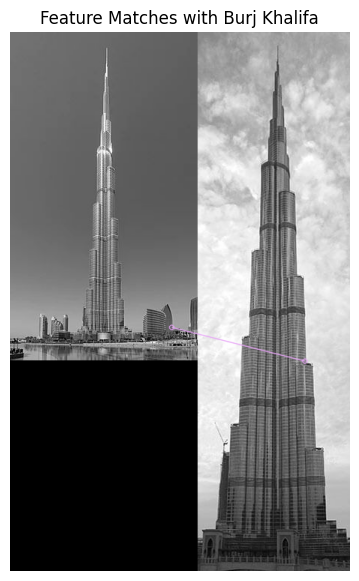

In [ ]:
match_all_landmarks_sift("/content/WhatsApp Image 2025-06-12 at 00.45.18.jpeg")


--- Landmark Match Probabilities ---
Atlantis: positive class probability = 0.0375
Burj Al Arab: positive class probability = 0.1230
Burj Khalifa: positive class probability = 0.8751
Dubai Frame: positive class probability = 0.1576

Best match: Burj Khalifa with confidence 0.8751


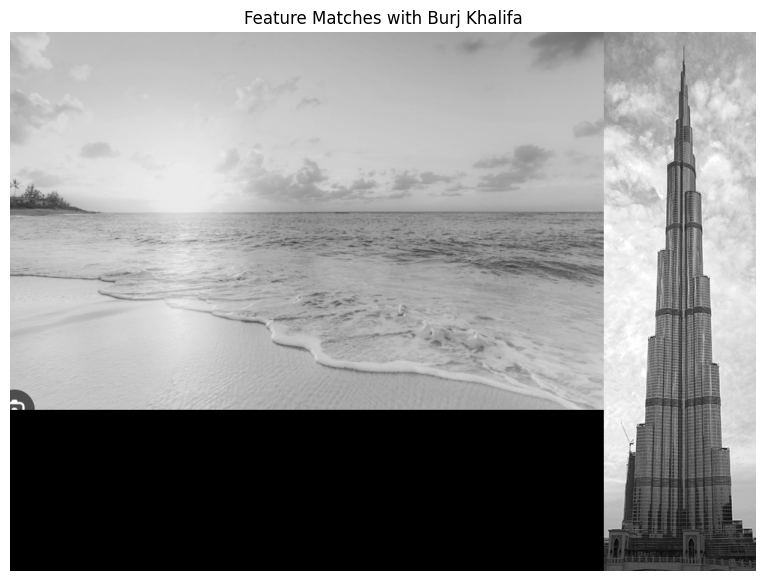

In [ ]:
match_all_landmarks_sift("/content/Screenshot 2025-06-17 at 1.34.52 AM.png")


--- Landmark Match Probabilities ---
Atlantis: positive class probability = 0.9278
Burj Al Arab: positive class probability = 0.0991
Burj Khalifa: positive class probability = 0.6726
Dubai Frame: positive class probability = 0.0872

Best match: Atlantis with confidence 0.9278


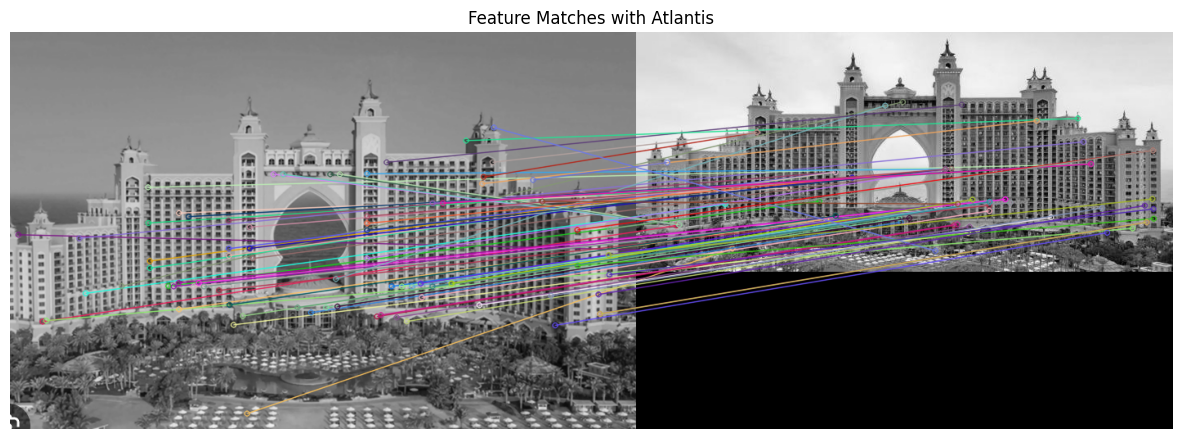

In [ ]:
match_all_landmarks_sift("/content/Screenshot 2025-06-17 at 1.36.06 AM.png")

In [ ]:
match_all_landmarks_sift("/content/Screenshot 2025-06-17 at 1.36.55 AM.png")


--- Landmark Match Probabilities ---
Atlantis: positive class probability = 0.2408
Burj Al Arab: positive class probability = 0.0722
Burj Khalifa: positive class probability = 0.0906
Dubai Frame: positive class probability = 0.1092

No confident match found. Rejected.


In [ ]:
match_all_landmarks_sift("/content/Screenshot 2025-06-17 at 1.38.59 AM.png")


--- Landmark Match Probabilities ---
Atlantis: positive class probability = 0.0358
Burj Al Arab: positive class probability = 0.2400
Burj Khalifa: positive class probability = 0.3409
Dubai Frame: positive class probability = 0.0878

No confident match found. Rejected.


In [ ]:
match_all_landmarks_sift("/content/Screenshot 2025-06-17 at 1.39.49 AM.png")


--- Landmark Match Probabilities ---
Atlantis: positive class probability = 0.0656
Burj Al Arab: positive class probability = 0.5266
Burj Khalifa: positive class probability = 0.5152
Dubai Frame: positive class probability = 0.0902

No confident match found. Rejected.


In [ ]:
match_all_landmarks_sift("/content/burj.png")


--- Landmark Match Probabilities ---
Atlantis: positive class probability = 0.0656
Burj Al Arab: positive class probability = 0.5266
Burj Khalifa: positive class probability = 0.5152
Dubai Frame: positive class probability = 0.0902

No confident match found. Rejected.
